In [16]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import libraries and load the processed data

This loads the clean file you saved at the end of Stage 1.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/gamepulse_players_stage1_clean.csv")

df.head()

,player_id,install_date,country,device_type,acquisition_channel,campaign_name,sessions_day_1,sessions_day_7,total_playtime_minutes,levels_completed,in_app_purchases_gbp,ad_views,retained_day_1,retained_day_7,retained_day_30,churned,basic_player_segment
0,P00001,2026-02-21,India,Android,Facebook Ads,FB_Retargeting,6,8,172.9,12,0.0,13,1,1,0,1,Churned
1,P00002,2026-01-15,United States,Android,Google Ads,GAds_Display,2,2,88.9,5,0.0,5,1,1,0,1,Churned
2,P00003,2026-03-13,India,iOS,Google Ads,GAds_AppInstall,5,3,103.8,10,0.0,6,1,1,0,1,Churned
3,P00004,2026-03-02,Japan,iOS,Google Ads,GAds_Display,4,4,109.8,10,0.0,5,1,1,0,1,Churned
4,P00005,2026-01-21,Canada,Android,Google Ads,GAds_AppInstall,1,0,39.6,6,0.0,0,1,0,0,1,At-Risk Early Drop-off


# Check the dataset again
just confirming the data loaded properly.

In [18]:
df.shape

(1200, 17)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_id               1200 non-null   object 
 1   install_date            1200 non-null   object 
 2   country                 1200 non-null   object 
 3   device_type             1200 non-null   object 
 4   acquisition_channel     1200 non-null   object 
 5   campaign_name           1200 non-null   object 
 6   sessions_day_1          1200 non-null   int64  
 7   sessions_day_7          1200 non-null   int64  
 8   total_playtime_minutes  1200 non-null   float64
 9   levels_completed        1200 non-null   int64  
 10  in_app_purchases_gbp    1200 non-null   float64
 11  ad_views                1200 non-null   int64  
 12  retained_day_1          1200 non-null   int64  
 13  retained_day_7          1200 non-null   int64  
 14  retained_day_30         1200 non-null   

# Calculate the main retention and churn KPIs
This gives the key numbers for the project

In [20]:
total_players = df["player_id"].nunique()
day_1_retention = df["retained_day_1"].mean() * 100
day_7_retention = df["retained_day_7"].mean() * 100
day_30_retention = df["retained_day_30"].mean() * 100
churn_rate = df["churned"].mean() * 100
total_revenue = df["in_app_purchases_gbp"].sum()

print(f"Total players: {total_players}")
print(f"Day 1 retention: {day_1_retention:.1f}%")
print(f"Day 7 retention: {day_7_retention:.1f}%")
print(f"Day 30 retention: {day_30_retention:.1f}%")
print(f"Churn rate: {churn_rate:.1f}%")
print(f"Total in-app purchase revenue: £{total_revenue:,.2f}")

Total players: 1200
Day 1 retention: 94.8%
Day 7 retention: 84.0%
Day 30 retention: 40.9%
Churn rate: 59.1%
Total in-app purchase revenue: £1,367.35


# Create a retention summary table
This creates a clean table that will later be use in README or report.

In [21]:
retention_summary = pd.DataFrame({
    "Metric": ["Day 1 Retention", "Day 7 Retention", "Day 30 Retention", "Churn Rate"],
    "Percentage": [day_1_retention, day_7_retention, day_30_retention, churn_rate]
})

retention_summary["Percentage"] = retention_summary["Percentage"].round(1)

retention_summary

,Metric,Percentage
0,Day 1 Retention,94.8
1,Day 7 Retention,84.0
2,Day 30 Retention,40.9
3,Churn Rate,59.1


# Plot the retention and churn KPIs
This creates the first chart.

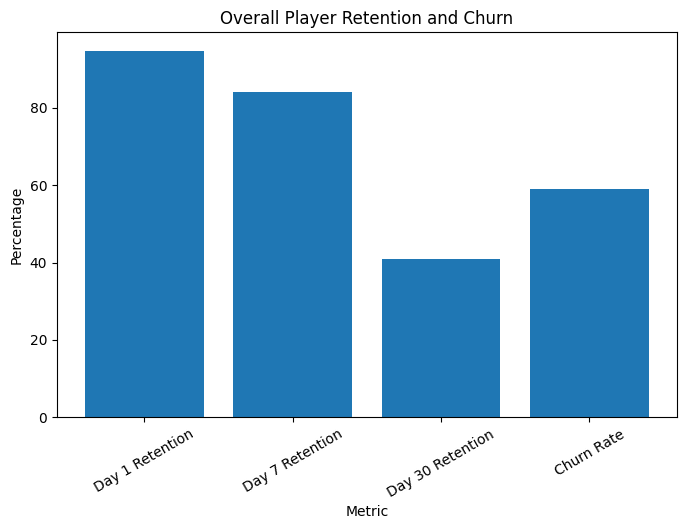

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(retention_summary["Metric"], retention_summary["Percentage"])
plt.title("Overall Player Retention and Churn")
plt.xlabel("Metric")
plt.ylabel("Percentage")
plt.xticks(rotation=30)
plt.show()

# Analyse retention by acquisition channel
This shows which marketing channels brought players who stayed longer.

In [23]:
retention_by_channel = df.groupby("acquisition_channel").agg(
    players=("player_id", "nunique"),
    day_1_retention=("retained_day_1", "mean"),
    day_7_retention=("retained_day_7", "mean"),
    day_30_retention=("retained_day_30", "mean"),
    churn_rate=("churned", "mean"),
    revenue=("in_app_purchases_gbp", "sum")
).reset_index()

retention_by_channel["day_1_retention"] = (retention_by_channel["day_1_retention"] * 100).round(1)
retention_by_channel["day_7_retention"] = (retention_by_channel["day_7_retention"] * 100).round(1)
retention_by_channel["day_30_retention"] = (retention_by_channel["day_30_retention"] * 100).round(1)
retention_by_channel["churn_rate"] = (retention_by_channel["churn_rate"] * 100).round(1)
retention_by_channel["revenue"] = retention_by_channel["revenue"].round(2)

retention_by_channel.sort_values("day_30_retention", ascending=False)

,acquisition_channel,players,day_1_retention,day_7_retention,day_30_retention,churn_rate,revenue
4,Organic,339,95.9,86.7,46.9,53.1,491.48
0,App Store Search,111,95.5,88.3,45.0,55.0,101.85
1,Facebook Ads,167,97.0,84.4,39.5,60.5,165.82
2,Google Ads,243,93.8,86.4,38.3,61.7,345.60
3,Influencer Campaign,149,91.9,76.5,36.2,63.8,169.76
5,TikTok Ads,191,94.2,79.1,36.1,63.9,92.84


# Chart Day 30 retention by acquisition channel
This is an important chart because it shows the quality of each channel.

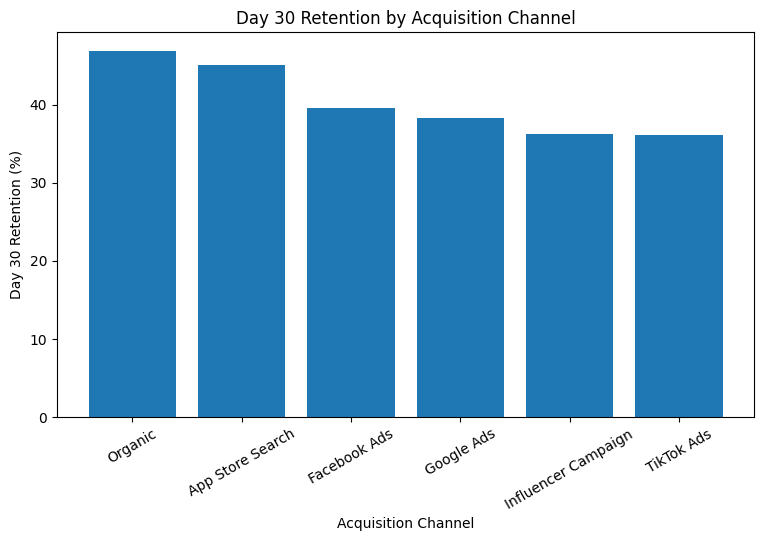

In [24]:
channel_chart = retention_by_channel.sort_values("day_30_retention", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(channel_chart["acquisition_channel"], channel_chart["day_30_retention"])
plt.title("Day 30 Retention by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Day 30 Retention (%)")
plt.xticks(rotation=30)
plt.show()

# Chart churn rate by acquisition channel
This shows which channels are losing more players.

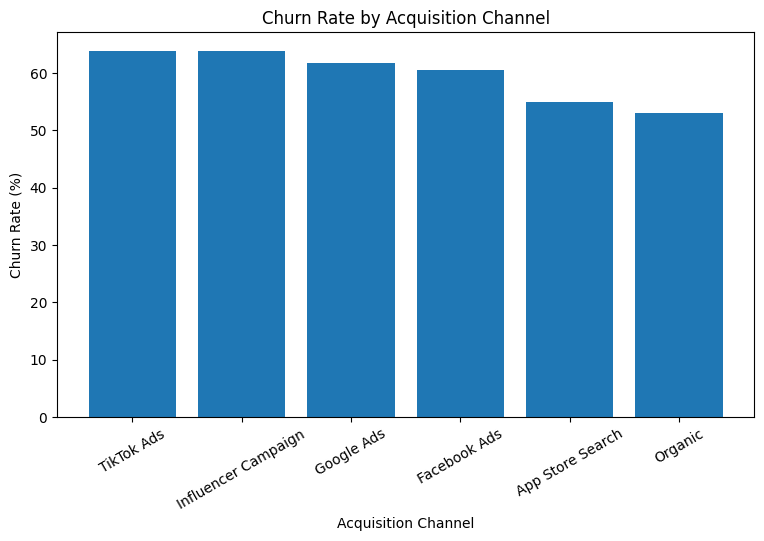

In [25]:
churn_chart = retention_by_channel.sort_values("churn_rate", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(churn_chart["acquisition_channel"], churn_chart["churn_rate"])
plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

# Analyse retention by country
This helps to see which countries have better long-term players.

In [26]:
retention_by_country = df.groupby("country").agg(
    players=("player_id", "nunique"),
    day_30_retention=("retained_day_30", "mean"),
    churn_rate=("churned", "mean"),
    revenue=("in_app_purchases_gbp", "sum")
).reset_index()

retention_by_country["day_30_retention"] = (retention_by_country["day_30_retention"] * 100).round(1)
retention_by_country["churn_rate"] = (retention_by_country["churn_rate"] * 100).round(1)
retention_by_country["revenue"] = retention_by_country["revenue"].round(2)

retention_by_country.sort_values("day_30_retention", ascending=False)

,country,players,day_30_retention,churn_rate,revenue
6,Nigeria,87,50.6,49.4,64.87
3,Germany,99,50.5,49.5,150.89
9,United States,260,45.4,54.6,241.72
2,France,104,40.4,59.6,178.81
1,Canada,80,40.0,60.0,171.83
4,India,124,38.7,61.3,149.84
7,South Korea,75,38.7,61.3,41.90
0,Brazil,88,36.4,63.6,111.82
8,United Kingdom,209,34.4,65.6,217.74
5,Japan,74,32.4,67.6,37.93


# Save Stage 2 summary files
This saves your Stage 2 results

In [27]:
import os

os.makedirs("../reports", exist_ok=True)

retention_summary.to_csv("../reports/stage2_overall_retention_summary.csv", index=False)
retention_by_channel.to_csv("../reports/stage2_retention_by_channel.csv", index=False)
retention_by_country.to_csv("../reports/stage2_retention_by_country.csv", index=False)

print("Stage 2 summary files saved successfully.")

Stage 2 summary files saved successfully.
